In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from scipy.spatial import cKDTree
from shapely.geometry import Point


In [7]:
# ### Calculate distance to neaerest park for each census tract centroid
from scipy.spatial import cKDTree
from shapely.geometry import Point

In [8]:
# Use OSMnx to get park locations in Philadelphia
gdfhealth = gpd.read_file("../../data/philly_neighborhoods.geojson")

health = ox.features_from_polygon(
    gdfhealth.unary_union,
    tags={'healthcare': ['hospital', 'pharmacy','clinic', 'dentist', 'emergency', 'nursing_home']}
)



print(f"✅ Found {len(health)} health in Philadelphia")
print(f"   Total park area: {health.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres

# Preview
print("\nSample health:")
print(health[['name', 'healthcare']].head(10))


# Keep only essential columns for saving
health_clean = health[['geometry', 'name', 'healthcare']].copy()

# Handle any NaN names
health_clean['name'] = health_clean['name'].fillna('Unnamed clinic')

# Save cleaned version
health_clean.to_file("../../data/philadelphia_healths_osm.geojson", driver='GeoJSON')

print(f"✅ Saved {len(health_clean)} parks to data/philadelphia_parks_osm.geojson")

# But keep the full version for analysis
print(f"\nFull parks dataset has {len(health.columns)} columns")
print(f"Available columns: {health.columns.tolist()[:10]}...")  # Show first 10


✅ Found 259 health in Philadelphia
   Total park area: 0 acres

Sample health:
                                         name healthcare
element_type osmid                                      
node         357374314     Wills Eye Hospital   hospital
             762450005               Rite Aid   pharmacy
             833393970           CVS Pharmacy   pharmacy
             833393978               Rite Aid   pharmacy
             1204731174          CVS Pharmacy   pharmacy
             1606861761              Rite Aid   pharmacy
             1687525009              Rite Aid   pharmacy
             2002969489  Olde Philly Pharmacy   pharmacy
             2012712694      Tang Pharmacy II   pharmacy
             2040451681          A&W Pharmacy   pharmacy
✅ Saved 259 parks to data/philadelphia_parks_osm.geojson

Full parks dataset has 95 columns
Available columns: ['addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'amenity', 'check_date', 'emergency', 'gnis:feature_id', 'he

C:\Users\astau\AppData\Local\Temp\ipykernel_31992\4180095320.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"   Total park area: {health.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres


In [9]:
# Get census tract centroids
gdfhealth = gdfhealth.to_crs(2272)
health = health.to_crs(2272)

tract_centroids = gdfhealth.copy()
tract_centroids['geometry'] = gdfhealth.geometry.centroid

# Get park boundaries (or centroids for small parks)
healthpoints = health.geometry.representative_point()

# Build spatial index
health_coords = np.array([(p.x, p.y) for p in healthpoints])
clinic = cKDTree(health_coords)

# Find nearest park for each census tract
tract_coords = np.array([(p.x, p.y) for p in tract_centroids.geometry])
distances, indices = clinic.query(tract_coords)

# Add distance (in feet for EPSG:2272)
gdfhealth['health_distance_ft'] = distances

In [10]:
gdfhealth

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,health_distance_ft
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((2719789.837 256235.538, 271981...",1342.514266
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((2733378.171 289259.945, 273281...",2870.335118
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((2685267.950 279747.336, 268527...",2279.107825
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((2678490.151 284400.400, 267851...",2062.854229
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((2686778.097 263597.187, 268692...",1883.548034
...,...,...,...,...,...,...,...
154,PENNSPORT,Pennsport,Pennsport,11823.233108,6.492473e+06,"MULTIPOLYGON (((2698530.956 228135.894, 269820...",2003.331593
155,NEWBOLD,Newbold,Newbold,10052.570885,5.876853e+06,"MULTIPOLYGON (((2692068.040 225421.124, 269199...",619.009882
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",2213.182275
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",1330.867390


In [11]:
# Common approach: inverse distance with maximum threshold
# 800m (1/2 mile) = ~2625 feet as maximum reasonable walking distance

# Min-max normalize park proximity so closer parks get higher scores
min_dist = gdfhealth['health_distance_ft'].min()
max_dist = gdfhealth['health_distance_ft'].max()

gdfhealth['health_proximity_score'] = 1 - (gdfhealth['health_distance_ft'] - min_dist) / (max_dist - min_dist)

gdfhealth

# Alternative: Use exponential decay
# tracts['park_proximity_score'] = np.exp(-tracts['park_distance_ft'] / 1312)  # 400m in feet

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,health_distance_ft,health_proximity_score
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((2719789.837 256235.538, 271981...",1342.514266,0.880118
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((2733378.171 289259.945, 273281...",2870.335118,0.735906
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((2685267.950 279747.336, 268527...",2279.107825,0.791712
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((2678490.151 284400.400, 267851...",2062.854229,0.812125
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((2686778.097 263597.187, 268692...",1883.548034,0.829050
...,...,...,...,...,...,...,...,...
154,PENNSPORT,Pennsport,Pennsport,11823.233108,6.492473e+06,"MULTIPOLYGON (((2698530.956 228135.894, 269820...",2003.331593,0.817743
155,NEWBOLD,Newbold,Newbold,10052.570885,5.876853e+06,"MULTIPOLYGON (((2692068.040 225421.124, 269199...",619.009882,0.948411
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",2213.182275,0.797935
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",1330.867390,0.881218


In [12]:
## SOCIAL SERVICES

In [13]:
# Use OSMnx to get park locations in Philadelphia
gdf = gpd.read_file("../../data/philly_neighborhoods.geojson")

service = ox.features_from_polygon(
    gdf.unary_union,
    tags={'amenity': ['post_office', 'social_facility','fire_station', 'library', 'police', 'childcare']}
)



print(f"✅ Found {len(service)} service in Philadelphia")
print(f"   Total service area: {service.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres

# Preview
print("\nSample health:")
print(service[['name', 'amenity']].head(10))


# Keep only essential columns for saving
service_clean = health[['geometry', 'name', 'amenity']].copy()

# Handle any NaN names
service_clean['name'] = service_clean['name'].fillna('Unnamed clinic')

# Save cleaned version
service_clean.to_file("../../data/philadelphia_services_osm.geojson", driver='GeoJSON')

print(f"✅ Saved {len(service_clean)} services to data/philadelphia_parks_osm.geojson")

# But keep the full version for analysis
print(f"\nFull service dataset has {len(service.columns)} columns")
print(f"Available columns: {service.columns.tolist()[:10]}...")  # Show first 10


✅ Found 644 service in Philadelphia
   Total service area: 0 acres

Sample health:
                                                          name  \
element_type osmid                                               
node         357371754       Chestnut Hill Station Post Office   
             357372188  Holmesburg Finance Station Post Office   
             357372206                       Sacred Heart Home   
             357372451     East Germantown Station Post Office   
             357372809          Germantown Station Post Office   
             357373001               Logan Station Post Office   
             357373123                     Mayfair Post Office   
             357373188     North Philadelphia West Post Office   
             357373289          Mount Airy Station Post Office   
             357373320        Hunting Park Station Post Office   

                                amenity  
element_type osmid                       
node         357371754      post_office 

C:\Users\astau\AppData\Local\Temp\ipykernel_31992\2451729029.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"   Total service area: {service.geometry.area.sum() / 43560:.0f} acres")  # Convert sq ft to acres


In [14]:
# Get census tract centroids
gdf = gdf.to_crs(2272)
service = service.to_crs(2272)

tract_centroids = gdf.copy()
tract_centroids['geometry'] = gdf.geometry.centroid

# Get park boundaries (or centroids for small parks)
servicepoints = service.geometry.representative_point()

# Build spatial index
service_coords = np.array([(p.x, p.y) for p in servicepoints])
serve = cKDTree(service_coords)

# Find nearest park for each census tract
tract_coords = np.array([(p.x, p.y) for p in tract_centroids.geometry])
distances, indices = serve.query(tract_coords)

# Add distance (in feet for EPSG:2272)
gdf['service_distance_ft'] = distances

In [15]:
gdf

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,service_distance_ft
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((2719789.837 256235.538, 271981...",1388.144438
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((2733378.171 289259.945, 273281...",2887.353926
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((2685267.950 279747.336, 268527...",1594.498993
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((2678490.151 284400.400, 267851...",1336.145630
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((2686778.097 263597.187, 268692...",1330.282531
...,...,...,...,...,...,...,...
154,PENNSPORT,Pennsport,Pennsport,11823.233108,6.492473e+06,"MULTIPOLYGON (((2698530.956 228135.894, 269820...",2153.200106
155,NEWBOLD,Newbold,Newbold,10052.570885,5.876853e+06,"MULTIPOLYGON (((2692068.040 225421.124, 269199...",202.598144
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",1766.447638
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",1067.495381


In [16]:
# Common approach: inverse distance with maximum threshold
# 800m (1/2 mile) = ~2625 feet as maximum reasonable walking distance

# Min-max normalize park proximity so closer parks get higher scores
min_dist = gdf['service_distance_ft'].min()
max_dist = gdf['service_distance_ft'].max()

gdf['service_proximity_score'] = 1 - (gdf['service_distance_ft'] - min_dist) / (max_dist - min_dist)
gdf


# Alternative: Use exponential decay
# tracts['park_proximity_score'] = np.exp(-tracts['park_distance_ft'] / 1312)  # 400m in feet

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,service_distance_ft,service_proximity_score
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((2719789.837 256235.538, 271981...",1388.144438,0.803371
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((2733378.171 289259.945, 273281...",2887.353926,0.581752
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((2685267.950 279747.336, 268527...",1594.498993,0.772866
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((2678490.151 284400.400, 267851...",1336.145630,0.811057
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((2686778.097 263597.187, 268692...",1330.282531,0.811924
...,...,...,...,...,...,...,...,...
154,PENNSPORT,Pennsport,Pennsport,11823.233108,6.492473e+06,"MULTIPOLYGON (((2698530.956 228135.894, 269820...",2153.200106,0.690277
155,NEWBOLD,Newbold,Newbold,10052.570885,5.876853e+06,"MULTIPOLYGON (((2692068.040 225421.124, 269199...",202.598144,0.978622
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",1766.447638,0.747448
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",1067.495381,0.850770


In [19]:
merged = gdf[["NAME", "geometry", "service_distance_ft", "service_proximity_score"]].merge(
    gdfhealth.drop(columns="geometry"),
    on="NAME",
    how="left"
)

merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=gdf.crs)
merged

,NAME,geometry,service_distance_ft,service_proximity_score,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,health_distance_ft,health_proximity_score
0,BRIDESBURG,"MULTIPOLYGON (((2719789.837 256235.538, 271981...",1388.144438,0.803371,Bridesburg,Bridesburg,27814.546521,4.458626e+07,1342.514266,0.880118
1,BUSTLETON,"MULTIPOLYGON (((2733378.171 289259.945, 273281...",2887.353926,0.581752,Bustleton,Bustleton,48868.458365,1.140504e+08,2870.335118,0.735906
2,CEDARBROOK,"MULTIPOLYGON (((2685267.950 279747.336, 268527...",1594.498993,0.772866,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,2279.107825,0.791712
3,CHESTNUT_HILL,"MULTIPOLYGON (((2678490.151 284400.400, 267851...",1336.145630,0.811057,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,2062.854229,0.812125
4,EAST_FALLS,"MULTIPOLYGON (((2686778.097 263597.187, 268692...",1330.282531,0.811924,East Falls,East Falls,27400.776417,4.057689e+07,1883.548034,0.829050
...,...,...,...,...,...,...,...,...,...,...
154,PENNSPORT,"MULTIPOLYGON (((2698530.956 228135.894, 269820...",2153.200106,0.690277,Pennsport,Pennsport,11823.233108,6.492473e+06,2003.331593,0.817743
155,NEWBOLD,"MULTIPOLYGON (((2692068.040 225421.124, 269199...",202.598144,0.978622,Newbold,Newbold,10052.570885,5.876853e+06,619.009882,0.948411
156,WEST_PASSYUNK,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",1766.447638,0.747448,West Passyunk,West Passyunk,10499.291848,6.494799e+06,2213.182275,0.797935
157,EAST_PASSYUNK,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",1067.495381,0.850770,East Passyunk,East Passyunk,10987.761846,6.502097e+06,1330.867390,0.881218


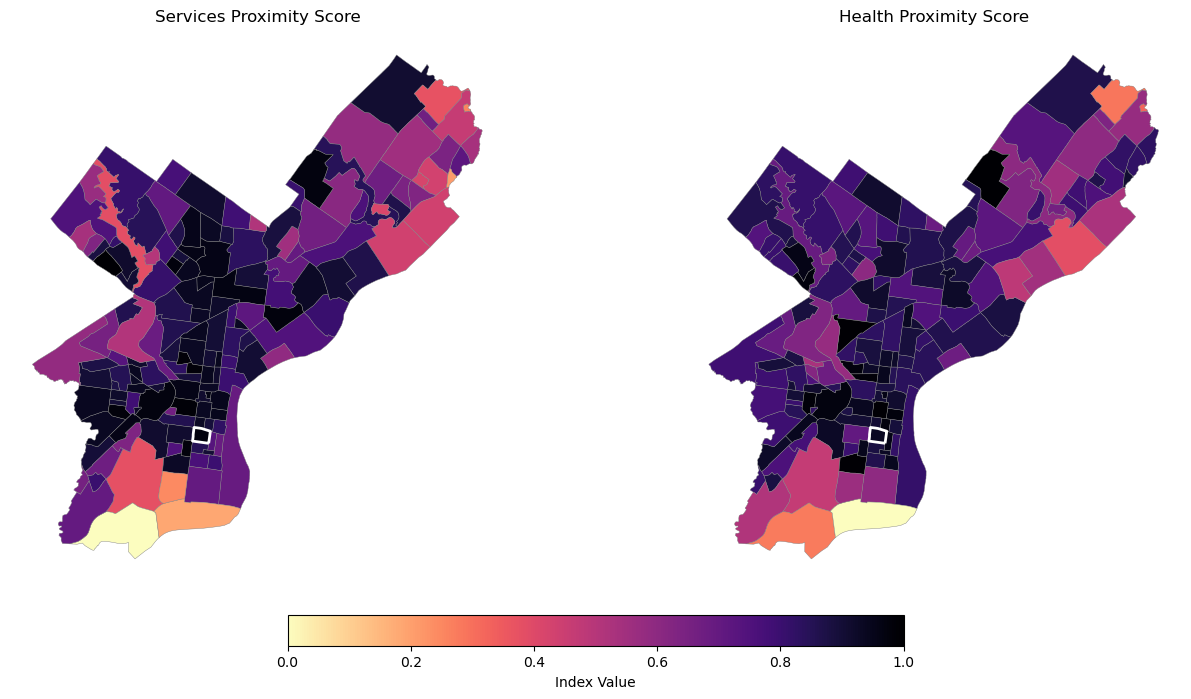

In [21]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as colors

east_passyunk = merged[merged["NAME"] == "PASSYUNK_SQUARE"]

# --- SHARED COLORMAP AND NORMALIZATION ---
vmin = min(
    merged["service_proximity_score"].min(),
    merged["health_proximity_score"].min(),
)

vmax = max(
    merged["service_proximity_score"].max(),
    merged["health_proximity_score"].max(),
)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "magma_r"  # safer built-in cmap

# --- CREATE FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax1, ax2, = axes

# -------------------------
# MAP 1 – Age 65+ Rate (Inverse)
# -------------------------
merged.plot(
    column="service_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax1
)
# Highlight East Passyunk tracts
east_passyunk.plot(ax=ax1, facecolor='none', edgecolor="white", linewidth=2)

ax1.set_title("Services Proximity Score")
ax1.axis("off")

# -------------------------
# MAP 2 – Disability Rate (Inverse)
# -------------------------
merged.plot(
    column="health_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax2
)
east_passyunk.plot(ax=ax2, facecolor='none', edgecolor="white", linewidth=2)

ax2.set_title("Health Proximity Score")
ax2.axis("off")


# -------------------------
# SHARED COLORBAR
# -------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal",
                    fraction=0.05, pad=0.05)
cbar.set_label("Index Value")

plt.show()

In [23]:
merged[merged['NAME'].str.contains('PASSYUNK', case=False, na=False)]


,NAME,geometry,service_distance_ft,service_proximity_score,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,health_distance_ft,health_proximity_score
107,PASSYUNK_SQUARE,"MULTIPOLYGON (((2695654.654 227659.753, 269243...",229.422936,0.974657,Passyunk Square,Passyunk Square,11751.503720,8.709396e+06,770.031832,0.934156
156,WEST_PASSYUNK,"MULTIPOLYGON (((2690249.664 225781.392, 268978...",1766.447638,0.747448,West Passyunk,West Passyunk,10499.291848,6.494799e+06,2213.182275,0.797935
157,EAST_PASSYUNK,"MULTIPOLYGON (((2695654.654 227659.753, 269559...",1067.495381,0.850770,East Passyunk,East Passyunk,10987.761846,6.502097e+06,1330.867390,0.881218


In [24]:
hoodgdf = gpd.read_file("../green_space/hoodgdf.gpkg")


In [26]:

# Step 2 — merge bike index
hoodgdf = hoodgdf.merge(
    merged[["NAME", "health_proximity_score"]],
    on="NAME",
    how="left"
)

# Step 3 — merge curb density index
hoodgdf = hoodgdf.merge(
    merged[["NAME", "service_proximity_score"]],
    on="NAME",
    how="left"
)

hoodgdf

KeyError: 'NAME'

In [ ]:
hoodgdf.to_file("hoodgdf.gpkg", layer="hood", driver="GPKG")


## percentile graphs 

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import percentileofscore
import plotly.graph_objects as go

### --------------------------
### 1. Define variables
### --------------------------

landuse_vars = [
    "service_proximity_score",
    "health_proximity_score",
    "sidewalk_index",
    "bike_index",
    "cartway_density_index",
    "ndvi_score",
    "park_proximity_score",
    "tree_score"
]

# Copy to avoid modifying main gdf
df_land = hoodgdf.copy()

### --------------------------
### 2. Compute percentiles
### --------------------------

for var in landuse_vars:
    df_land[var + "_pct"] = df_land[var].apply(
        lambda x: np.nan if pd.isna(x) else percentileofscore(df_land[var].dropna(), x)
    )

# Extract East Passyunk tracts
ep_land = df_land[df_land["Name"].str.contains("PASSYUNK", case=False)]

# Clean selection
ep_land = ep_land[["Name"] + [v+"_pct" for v in landuse_vars]]

### --------------------------
### 3. Interactive Plotly chart
### --------------------------

fig = go.Figure()

x_labels = [v.replace("_", " ").title() for v in landuse_vars]

for _, row in ep_land.iterrows():
    name = row["Name"]
    values = row[[v+"_pct" for v in landuse_vars]].values
    
    fig.add_trace(go.Bar(
        x=x_labels,
        y=values,
        name=name,
        text=[f"{v:.1f}" if not pd.isna(v) else "Missing" for v in values],
        textposition="outside",
        hovertemplate="<b>%{x}</b><br>Percentile: %{y:.1f}<extra>" + name + "</extra>"
    ))

fig.update_layout(
    title="Citywide Percentile Profile — East Passyunk Land Use & Service Variables",
    yaxis_title="Percentile (0–100)",
    barmode='group',
    bargap=0.12,
    template="plotly_white",
    height=650,
    xaxis_tickangle=-45,
)

fig.show()


KeyError: 'service_proximity_score'

## ingore

## A. Load Data & Health Locations

In [28]:
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from scipy.spatial import cKDTree
from shapely.geometry import Point

# Load neighborhoods (NOT census tracts)
hoods = gpd.read_file("../../data/philly_neighborhoods.geojson")
hoods_2272 = hoods.to_crs(2272)

# --------------------
# HEALTH LOCATIONS
# --------------------
health = ox.features_from_polygon(
    hoods.unary_union,
    tags={'healthcare': ['hospital', 'pharmacy', 'clinic', 'dentist', 'emergency', 'nursing_home']}
)

print("Found health features:", len(health))

# Clean
health = health.to_crs(2272)
health_clean = health[['geometry', 'name', 'healthcare']].copy()
health_clean['name'] = health_clean['name'].fillna("Unnamed Facility")
health_clean.to_file("../../data/philadelphia_health_osm.geojson", driver="GeoJSON")


Found health features: 259


## B. Compute Neighborhood → Nearest Health Distance

In [29]:
# Neighborhood centroids
hood_centroids = hoods_2272.copy()
hood_centroids["geometry"] = hood_centroids.geometry.centroid

# Representative points of facilities
health_points = health.geometry.representative_point()
health_coords = np.array([(p.x, p.y) for p in health_points])

tree = cKDTree(health_coords)

hood_coords = np.array([(p.x, p.y) for p in hood_centroids.geometry])
distances, _ = tree.query(hood_coords)

hoods_2272["health_distance_ft"] = distances

# Normalize to score (closer = higher score)
min_d = hoods_2272["health_distance_ft"].min()
max_d = hoods_2272["health_distance_ft"].max()

hoods_2272["health_proximity_score"] = 1 - (hoods_2272["health_distance_ft"] - min_d) / (max_d - min_d)


## C. SOCIAL SERVICES LOCATIONS

In [30]:
# SOCIAL SERVICE AMENITIES
services = ox.features_from_polygon(
    hoods.unary_union,
    tags={'amenity': ['post_office', 'social_facility', 'fire_station', 'library', 'police', 'childcare']}
)

services = services.to_crs(2272)
print("Found services:", len(services))

services_clean = services[['geometry', 'name', 'amenity']].copy()
services_clean['name'] = services_clean['name'].fillna("Unnamed Service")
services_clean.to_file("../../data/philadelphia_services_osm.geojson", driver="GeoJSON")


Found services: 644


## D. Compute Neighborhood → Nearest Service Distance

In [31]:
service_points = services.geometry.representative_point()
service_coords = np.array([(p.x, p.y) for p in service_points])

tree_s = cKDTree(service_coords)

distances_s, _ = tree_s.query(hood_coords)
hoods_2272["service_distance_ft"] = distances_s

min_s = hoods_2272["service_distance_ft"].min()
max_s = hoods_2272["service_distance_ft"].max()

hoods_2272["service_proximity_score"] = 1 - (hoods_2272["service_distance_ft"] - min_s) / (max_s - min_s)


## E. MERGE INTO hoodgdf (Correct Join)

In [32]:
hoodgdf = gpd.read_file("../green_space/hoodgdf.gpkg")

# MERGE health proximity
hoodgdf = hoodgdf.merge(
    hoods_2272[["NAME", "health_proximity_score"]],
    left_on="Name",
    right_on="NAME",
    how="left"
).drop(columns="NAME")

# MERGE service proximity
hoodgdf = hoodgdf.merge(
    hoods_2272[["NAME", "service_proximity_score"]],
    left_on="Name",
    right_on="NAME",
    how="left"
).drop(columns="NAME")

hoodgdf.to_file("hoodgdf.gpkg", layer="hood", driver="GPKG")


## F. FIXED: Percentile Plot (No Missing Columns Errors)

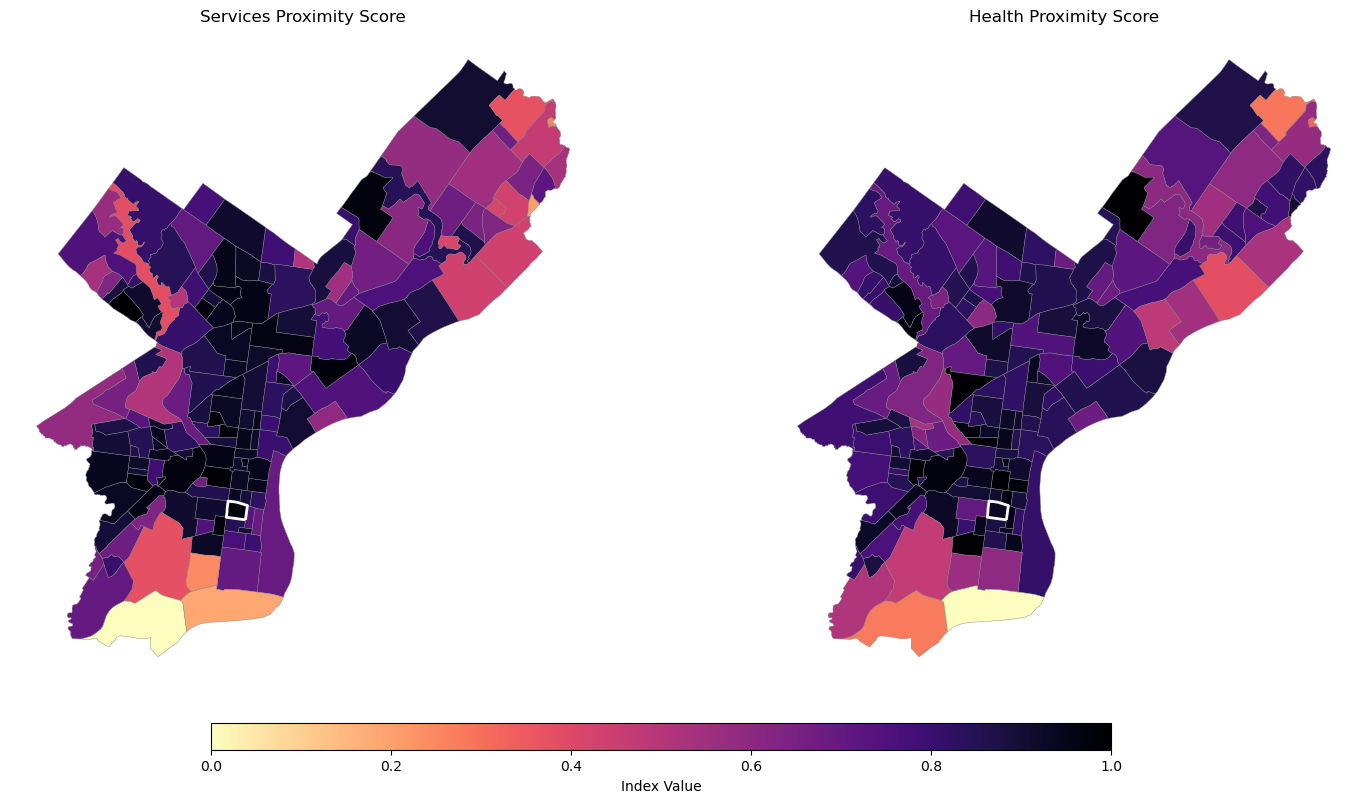

In [36]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as colors

east_passyunk = merged[merged["NAME"] == "PASSYUNK_SQUARE"]

# --- SHARED COLORMAP AND NORMALIZATION ---
vmin = min(
    merged["service_proximity_score"].min(),
    merged["health_proximity_score"].min(),
)

vmax = max(
    merged["service_proximity_score"].max(),
    merged["health_proximity_score"].max(),
)

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = "magma_r"

# --- CREATE FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
ax1, ax2 = axes

# -------------------------
# MAP 1 – Services
# -------------------------
merged.plot(
    column="service_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax1
)
east_passyunk.plot(ax=ax1, facecolor='none', edgecolor="white", linewidth=2)
ax1.set_title("Services Proximity Score")
ax1.axis("off")

# -------------------------
# MAP 2 – Health
# -------------------------
merged.plot(
    column="health_proximity_score",
    cmap=cmap,
    norm=norm,
    edgecolor="grey",
    linewidth=0.3,
    ax=ax2
)
east_passyunk.plot(ax=ax2, facecolor='none', edgecolor="white", linewidth=2)
ax2.set_title("Health Proximity Score")
ax2.axis("off")

# -------------------------
# LOWERED COLORBAR
# -------------------------
# create a new axis *below* both maps
cbar_ax = fig.add_axes([0.25, 0.08, 0.50, 0.03])  
# [left, bottom, width, height]

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Index Value")

plt.subplots_adjust(bottom=0.15)  # ensures space for the legend
plt.show()
